# Activité 3 — Modélisation appliquée : projet CrediTrust Scoring

**Objectif métier** : CrediTrust est une institution de micro-crédit qui souhaite un outil
d'aide à la décision pour estimer le **risque** associé à une demande de prêt.

On dispose du fichier `loan_data.csv` (jeu de données historique de demandes de prêt).
Dans ce notebook, on va :

1. Explorer les données pour faire émerger les facteurs de risque bancaire.
2. Prétraiter les données proprement (valeurs manquantes, encodage, mise à l'échelle) **sans fuite de données**.
3. Entraîner plusieurs modèles de classification binaire.
4. Évaluer les modèles avec un regard **métier** : dans le crédit, un **Faux Négatif**
   (un dossier risqué prédit comme sûr) coûte beaucoup plus cher qu'un Faux Positif
   (un bon dossier prédit comme risqué). On priorise donc le **rappel (recall)** sur la classe "risque".
5. Sélectionner le meilleur modèle et interpréter les variables qui pèsent le plus dans la décision.


## 1. Chargement et premier coup d'œil

Le fichier `loan_data.csv` est le jeu de données historique "Loan Prediction". Chaque ligne est une
demande de prêt, avec des informations sur le demandeur (revenus, situation familiale, historique de
crédit...) et le statut final `Loan_Status` (`Y` = prêt accordé, `N` = prêt refusé).

⚠️ Certaines lignes n'ont pas de `Loan_Status` renseigné : ce sont des dossiers pour lesquels on n'a
pas de décision historique. On ne peut ni les entraîner ni les évaluer dessus (on ne connaît pas la
bonne réponse), donc on les retire dès le départ.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


In [2]:
df_raw = pd.read_csv("../data/loan_data.csv")
print("Dimensions brutes :", df_raw.shape)
df_raw.head()


Dimensions brutes : (981, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print("Nombre de lignes sans Loan_Status connu :", df_raw["Loan_Status"].isna().sum())

df = df_raw.dropna(subset=["Loan_Status"]).drop(columns=["Loan_ID"]).reset_index(drop=True)
print("Dimensions après nettoyage (Loan_Status connu, Loan_ID retiré) :", df.shape)
df.head()


Nombre de lignes sans Loan_Status connu : 367
Dimensions après nettoyage (Loan_Status connu, Loan_ID retiré) : (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Pourquoi retirer `Loan_ID`** : c'est un identifiant unique par dossier, il n'a aucune valeur
prédictive et un modèle pourrait apprendre à "mémoriser" les identifiants au lieu d'apprendre les
vrais facteurs de risque.


## 2. Analyse exploratoire (EDA)

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    str    
 1   Married            611 non-null    str    
 2   Dependents         599 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      582 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 57.7 KB


In [5]:
print("Valeurs manquantes par colonne :")
df.isna().sum().sort_values(ascending=False)


Valeurs manquantes par colonne :


Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
ApplicantIncome       0
CoapplicantIncome     0
Property_Area         0
Loan_Status           0
dtype: int64

Loan_Status
Y    422
N    192
Name: count, dtype: int64

Part de refus (N) : 31.3 %


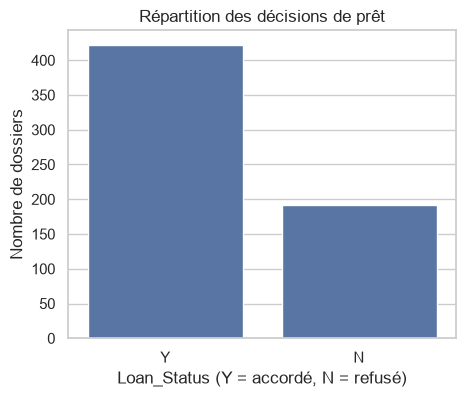

In [6]:
target_counts = df["Loan_Status"].value_counts()
print(target_counts)
print()
print("Part de refus (N) :", round((target_counts["N"] / target_counts.sum()) * 100, 1), "%")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Loan_Status", order=["Y", "N"])
plt.title("Répartition des décisions de prêt")
plt.xlabel("Loan_Status (Y = accordé, N = refusé)")
plt.ylabel("Nombre de dossiers")
plt.show()


**Observation** : les classes sont déséquilibrées (nettement plus de prêts accordés que de refus).
C'est important pour la suite : l'accuracy seule serait trompeuse (un modèle qui prédit toujours
"accordé" aurait déjà une bonne accuracy sans être utile). C'est pour ça qu'on va aussi regarder
précision, rappel et F1 sur la classe "risque".


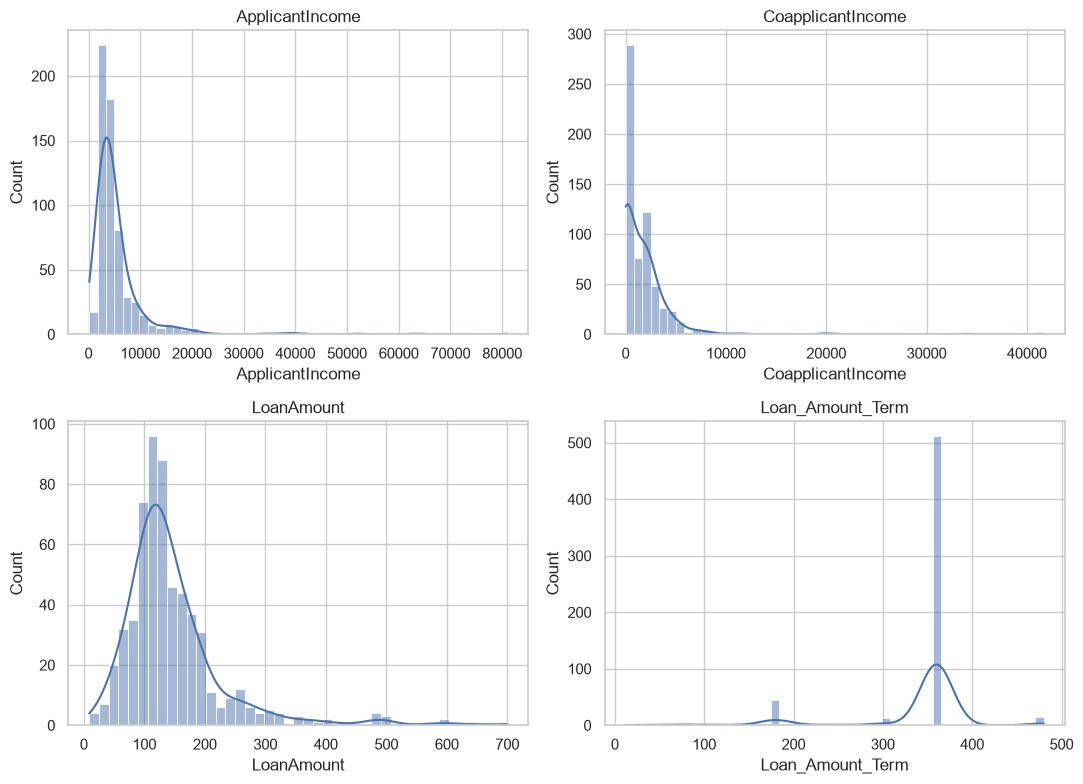

In [7]:
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


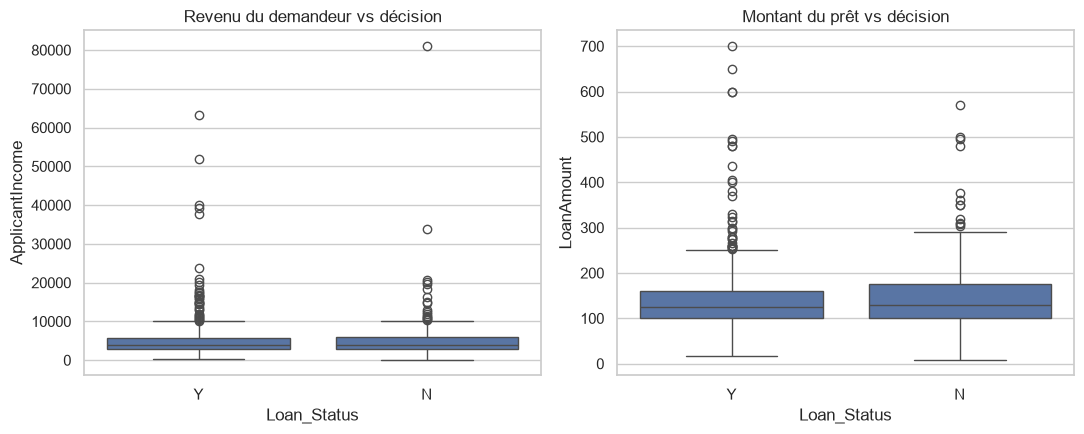

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df, x="Loan_Status", y="ApplicantIncome", order=["Y", "N"], ax=axes[0])
axes[0].set_title("Revenu du demandeur vs décision")
sns.boxplot(data=df, x="Loan_Status", y="LoanAmount", order=["Y", "N"], ax=axes[1])
axes[1].set_title("Montant du prêt vs décision")
plt.tight_layout()
plt.show()


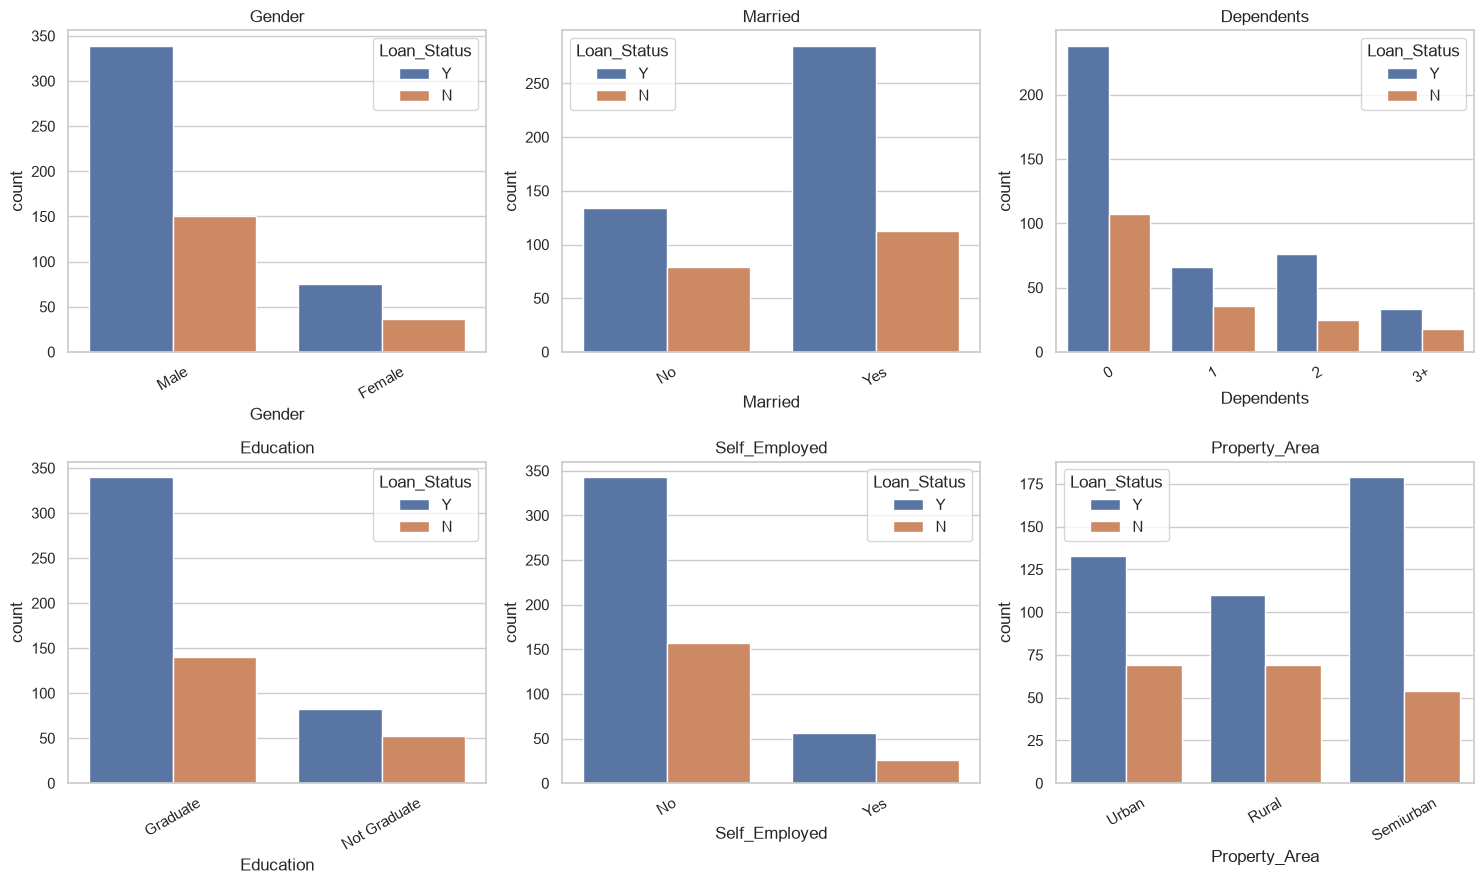

In [9]:
categorical_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.ravel(), categorical_cols):
    sns.countplot(data=df, x=col, hue="Loan_Status", hue_order=["Y", "N"], ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


In [10]:
credit_ct = pd.crosstab(df["Credit_History"], df["Loan_Status"], normalize="index") * 100
print("Taux d'accord/refus selon l'historique de crédit (%) :")
credit_ct.round(1)


Taux d'accord/refus selon l'historique de crédit (%) :


Loan_Status,N,Y
Credit_History,,
0.0,92.1,7.9
1.0,20.4,79.6


**Facteur de risque majeur qui ressort** : `Credit_History` (le demandeur a-t-il déjà remboursé un
crédit correctement par le passé, 1 = oui, 0 = non). Le taux de refus explose quand
`Credit_History = 0`. C'est cohérent avec l'intuition bancaire : le passé de remboursement est un
très bon prédicteur du risque futur.


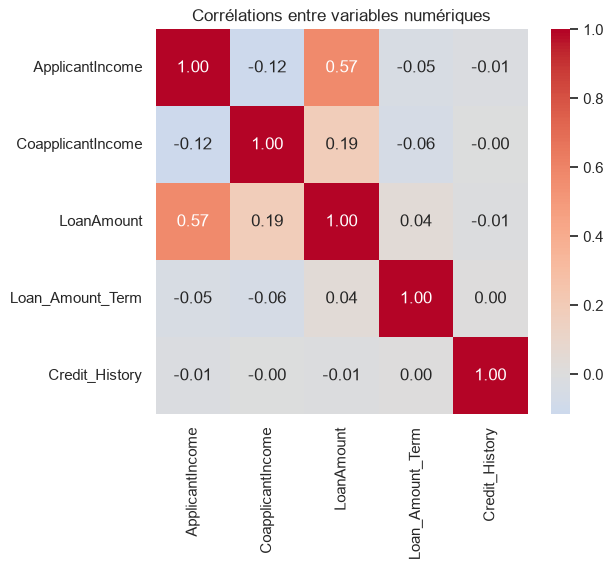

In [11]:
corr = df[numeric_cols + ["Credit_History"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations entre variables numériques")
plt.show()


## 3. Prétraitement (sans fuite de données)

Règle d'or : **on ne calcule jamais une statistique (moyenne, médiane, catégorie la plus fréquente,
écart-type...) sur l'ensemble des données avant d'avoir séparé train et test.** Sinon, des
informations du jeu de test "fuitent" dans l'entraînement, et les performances mesurées sont
trop optimistes par rapport à la réalité.

Ici, on va :
1. Séparer `X` (variables explicatives) et `y` (cible).
2. Faire le `train_test_split` **avant** tout traitement.
3. Construire un pipeline de prétraitement qu'on `fit` uniquement sur le train, puis qu'on applique
   (`transform`) sur le train et le test.

**Choix de la cible** : on encode `y = 1` si le dossier a été **refusé** (`Loan_Status == "N"`,
dossier jugé risqué) et `y = 0` s'il a été accordé. Ainsi la classe "1" représente le **risque**,
et un **Faux Négatif** = un dossier réellement risqué (y=1) prédit comme sûr (y=0) — exactement le
cas qu'on veut éviter dans un outil de scoring crédit.


In [12]:
y = (df["Loan_Status"] == "N").astype(int)
X = df.drop(columns=["Loan_Status"])

print("Distribution de la cible (1 = risque / refus) :")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("\nTrain :", X_train.shape, " Test :", X_test.shape)


Distribution de la cible (1 = risque / refus) :
Loan_Status
0    422
1    192
Name: count, dtype: int64

Train : (491, 11)  Test : (123, 11)


In [13]:
numeric_features = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
categorical_features = ["Gender", "Married", "Dependents", "Education", "Self_Employed",
                         "Property_Area", "Credit_History"]

# Credit_History est un indicateur (0/1) : on le traite comme une catégorie, pas comme une
# quantité qu'on ferait la moyenne, d'où le cast en texte.
X_train = X_train.copy()
X_test = X_test.copy()
to_category = lambda v: str(v) if pd.notna(v) else np.nan
X_train["Credit_History"] = X_train["Credit_History"].map(to_category)
X_test["Credit_History"] = X_test["Credit_History"].map(to_category)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


**Pourquoi une imputation différente pour le numérique et le catégoriel ?**
- Numérique (revenus, montant du prêt...) : on remplace les valeurs manquantes par la **médiane**
  (plus robuste que la moyenne face aux valeurs extrêmes de revenu).
- Catégoriel (genre, statut marital, historique de crédit...) : on remplace par la **catégorie la
  plus fréquente**, la médiane n'a pas de sens sur du texte.

Le `ColumnTransformer` + les `Pipeline` garantissent que ces statistiques (médiane, mode, moyenne/
écart-type du `StandardScaler`) sont apprises **uniquement sur `X_train`** grâce au futur `.fit()`,
puis réappliquées telles quelles sur `X_test`.


## 4. Entraînement de plusieurs modèles de classification

On compare 5 modèles, chacun encapsulé dans un pipeline complet
`prétraitement -> modèle`, pour garantir qu'aucun traitement n'est fait "à la main" en dehors
du `.fit()` sur le train (donc pas de fuite de données possible).


In [14]:
models = {
    "Régression Logistique": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Arbre de Décision": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM (linéaire)": SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
}

fitted_pipelines = {}
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    fitted_pipelines[name] = pipeline
    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Précision (risque)": precision_score(y_test, y_pred),
        "Rappel (risque)": recall_score(y_test, y_pred),
        "F1 (risque)": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values("Rappel (risque)", ascending=False).reset_index(drop=True)
results_df


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Modèle,Accuracy,Précision (risque),Rappel (risque),F1 (risque)
0,Arbre de Décision,0.658537,0.454545,0.526316,0.487805
1,Random Forest,0.756098,0.633333,0.500000,0.558824
2,Régression Logistique,0.813008,0.857143,0.473684,0.610169
3,SVM (linéaire),0.813008,0.894737,0.447368,0.596491
4,KNN,0.764228,0.695652,0.421053,0.524590


## 5. Évaluation orientée métier : priorité au rappel (minimiser les Faux Négatifs)

Rappel de la lecture métier :
- **Faux Négatif** = un dossier réellement risqué (y=1) que le modèle classe comme sûr (y=0).
  → CrediTrust accorderait un crédit à quelqu'un qui ne le remboursera probablement pas. **C'est
  le pire cas** : perte financière directe.
- **Faux Positif** = un bon dossier (y=0) classé comme risqué (y=1).
  → CrediTrust refuserait à tort un client fiable. Ennuyeux (manque à gagner) mais moins coûteux
  qu'un défaut de paiement.

On regarde donc en priorité le **rappel sur la classe "risque"**, sans ignorer le F1 (un modèle qui
prédit "tout le monde est risqué" aurait un rappel de 100% mais serait inutilisable en pratique,
d'où l'intérêt de regarder aussi la précision et le F1).


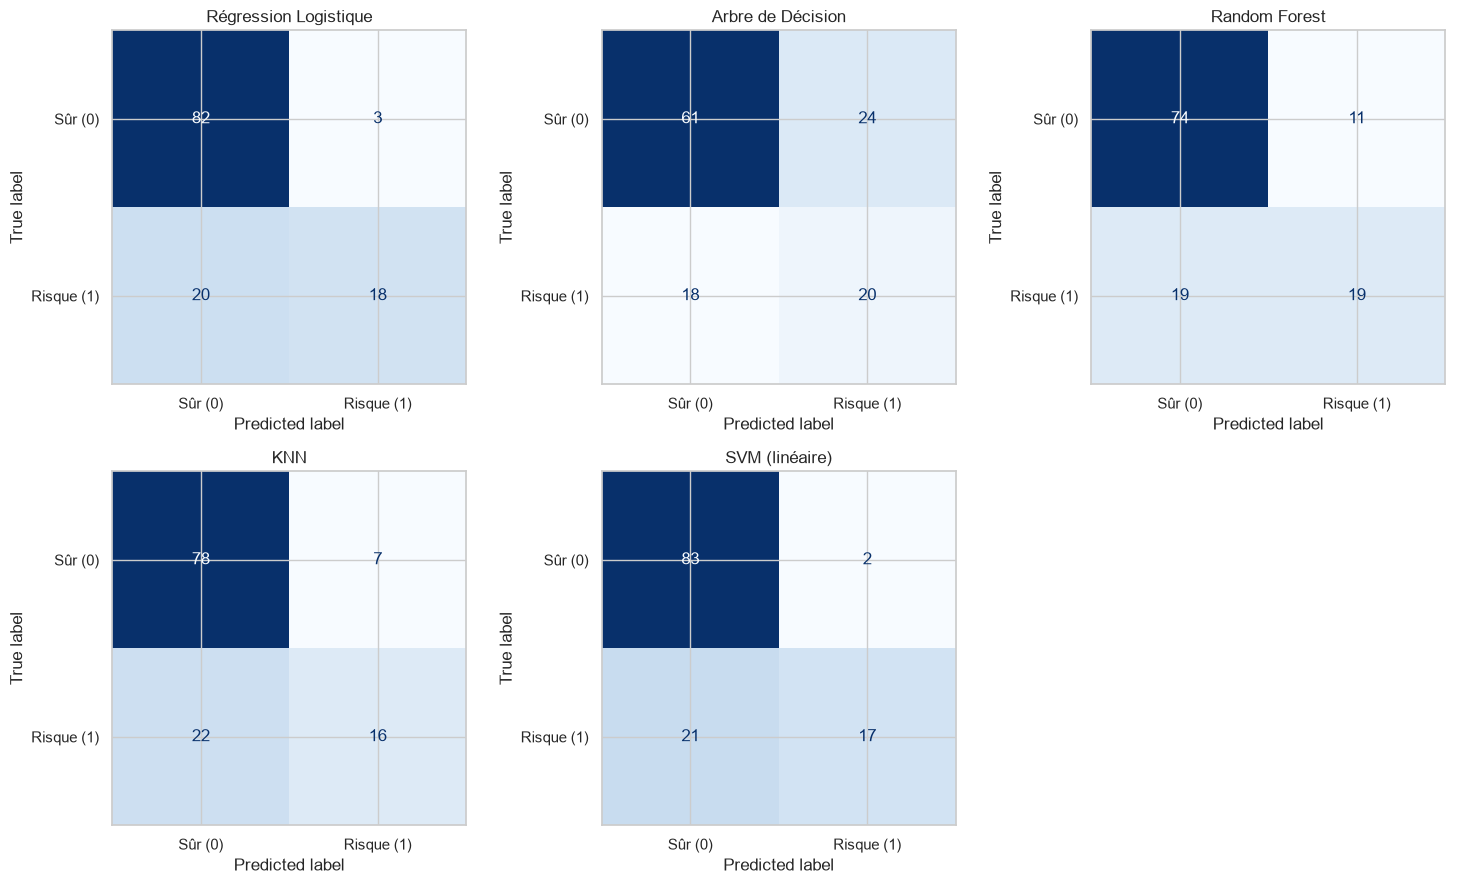

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, pipeline) in zip(axes.ravel(), fitted_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sûr (0)", "Risque (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()


In [16]:
best_model_name = results_df.iloc[0]["Modèle"]
print(f"Meilleur rappel sur la classe risque : {best_model_name}\n")
print(classification_report(
    y_test, fitted_pipelines[best_model_name].predict(X_test),
    target_names=["Sûr (0)", "Risque (1)"]
))


Meilleur rappel sur la classe risque : Arbre de Décision

              precision    recall  f1-score   support

     Sûr (0)       0.77      0.72      0.74        85
  Risque (1)       0.45      0.53      0.49        38

    accuracy                           0.66       123
   macro avg       0.61      0.62      0.62       123
weighted avg       0.67      0.66      0.66       123



## 6. Sélection du modèle et interprétabilité

On regarde les coefficients de la **Régression Logistique** (modèle linéaire, facilement
interprétable : un coefficient positif augmente la probabilité de risque, un coefficient négatif
la diminue) et les **importances de variables** de la **Random Forest** (modèle non-linéaire, plus
performant en général mais moins directement lisible).


/var/folders/y2/5dcsv6wn2lsg2qp8860v8sxr0000gn/T/ipykernel_36842/3231325842.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Variable",


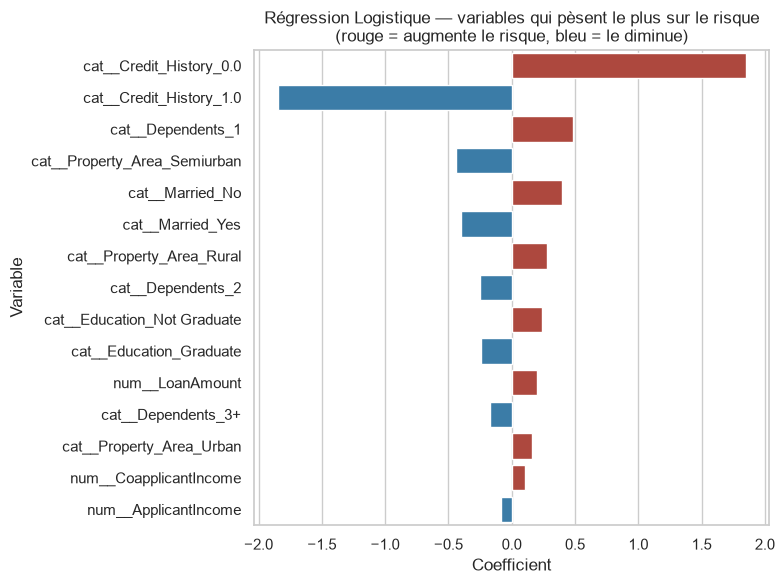

In [17]:
log_reg_pipeline = fitted_pipelines["Régression Logistique"]
feature_names = log_reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = log_reg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({"Variable": feature_names, "Coefficient": coefficients})
coef_df = coef_df.sort_values("Coefficient", key=abs, ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x="Coefficient", y="Variable",
            palette=["#c0392b" if c > 0 else "#2980b9" for c in coef_df["Coefficient"]])
plt.title("Régression Logistique — variables qui pèsent le plus sur le risque\n(rouge = augmente le risque, bleu = le diminue)")
plt.tight_layout()
plt.show()


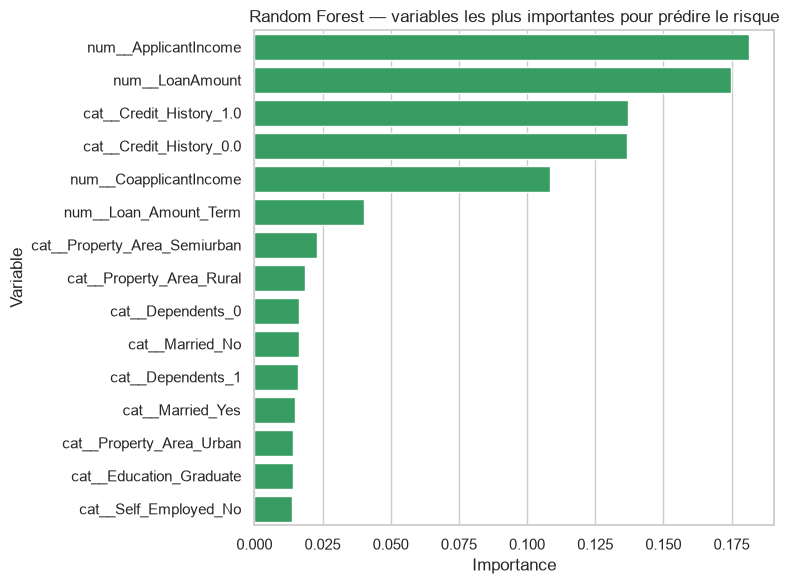

In [18]:
rf_pipeline = fitted_pipelines["Random Forest"]
rf_feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({"Variable": rf_feature_names, "Importance": importances})
importance_df = importance_df.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="Importance", y="Variable", color="#27ae60")
plt.title("Random Forest — variables les plus importantes pour prédire le risque")
plt.tight_layout()
plt.show()


## 7. Conclusion

- **Facteur de risque dominant** : `Credit_History` (avoir déjà bien remboursé un crédit par le
  passé) ressort systématiquement comme la variable la plus déterminante, aussi bien dans la
  Régression Logistique que dans la Random Forest — cohérent avec l'EDA de la partie 2.
- **Modèle retenu** : celui avec le meilleur rappel sur la classe "risque" (voir tableau de la
  partie 4), car dans ce contexte métier, laisser passer un dossier risqué coûte plus cher que
  refuser à tort un bon dossier.
- **Limite du jeu de données** : `Loan_Status` reflète une décision d'octroi passée (accordé/
  refusé par un processus historique), pas un vrai défaut de paiement constaté. Le modèle apprend
  donc à reproduire les critères de décision historiques, pas directement le risque réel de
  défaut — un vrai projet CrediTrust nécessiterait un historique de remboursement/défaut pour
  affiner ce point.
